# 00 · *Where's Waldo?* — the problem, the cast, and our benchmark

> *"Somewhere on this page is Waldo. He wears a red-and-white striped shirt, a bobble
> hat, and round glasses — but he is lost in a crowd of hundreds. Can you find him?"*

**The premise.** *Where's Waldo?* (Martin Handford, 1987; *Where's Wally?* outside North
America) is a series of busy two-page illustrations packed with hundreds of tiny figures.
The reader must locate **Waldo** — a deliberately unremarkable man in a red-and-white
striped shirt — hidden among a sea of look-alikes and visual noise. The difficulty is
engineered: the scenes are dense, and the artist plants **near-duplicates** that share
Waldo's colours, stripes, or silhouette to fool the eye.

That is exactly what makes it a clean testbed for a recogniser: a **target with a crisp
visual signature** (red/white horizontal stripes + bobble hat + glasses) that must be
told apart from a cast of look-alikes the artist plants to fool the eye. This notebook
introduces that cast, is honest about what a synthetic stand-in can and can't capture,
and then builds the benchmark the rest of the study runs on.

*Character art and lore below are from the [Where's Waldo? Wiki](https://waldo.fandom.com/),
used here for research motivation.*

In [1]:
import sys, importlib
sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image as _PILImage
import synthetic as S, characters as C, detector as D, bench
for _m in (S, C, D, bench): importlib.reload(_m)
import wisardpkg as wp
plt.rcParams['figure.dpi'] = 110
np.set_printoptions(suppress=True)
ASSETS = './assets/characters'
def load_char(k): return np.asarray(_PILImage.open(f'{ASSETS}/{k}.png').convert('RGBA'))

## The cast — five recurring characters
Besides Waldo, the same handful of characters appear throughout the books: **Odlaw**,
**Wenda**, **Wizard Whitebeard**, and Waldo's dog **Woof**. Each was drawn to *resemble*
Waldo in some way — that resemblance is what makes spotting the real one hard — but each
differs in one recognisable way.

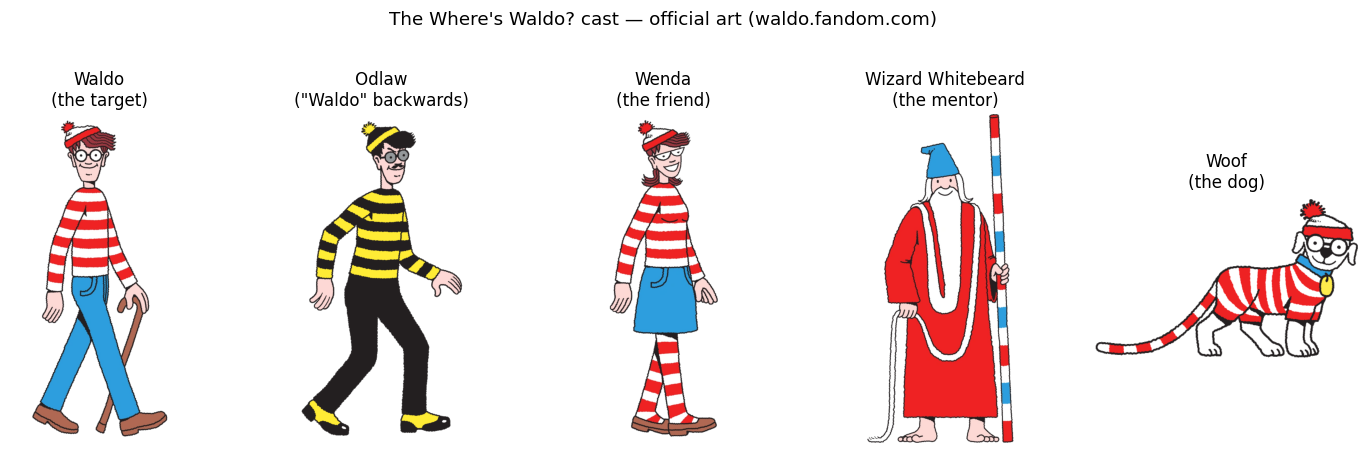

In [2]:
cast = [
    ('waldo',  'Waldo',  'the target'),
    ('odlaw',  'Odlaw',  '"Waldo" backwards'),
    ('wenda',  'Wenda',  'the friend'),
    ('wizard', 'Wizard Whitebeard', 'the mentor'),
    ('woof',   'Woof',   'the dog'),
]
fig, ax = plt.subplots(1, 5, figsize=(13, 4))
for a, (k, name, tag) in zip(ax, cast):
    a.imshow(load_char(k))
    a.set_title(f'{name}\n({tag})', fontsize=11); a.axis('off')
plt.suptitle("The Where's Waldo? cast — official art (waldo.fandom.com)", y=1.02)
plt.tight_layout(); plt.show()

### Who they are

- **Waldo** *(the target).* "Tallish, lightish." His look is the anchor of the whole
  series: a **red-and-white horizontally striped shirt**, blue trousers, striped socks,
  **round glasses**, and a **red-and-white bobble hat**, walking stick in hand. He wanders
  "all over the world, through time, and to distant magical lands."

- **Odlaw** *("Waldo's awful opposite", the villain).* His name is **Waldo spelled
  backwards**, and his design is a deliberate inversion: the same striped-shirt-and-
  bobble-hat silhouette, but **black-and-yellow** instead of red-and-white, with a sly
  moustache. All he wants is Waldo's magic walking stick.

- **Wenda** *(Waldo's friend, "the one who takes the pictures").* The closest to Waldo of
  all — **the same red-and-white stripes, glasses, and bobble hat**, with a blue skirt. In
  the books you tell the two apart mainly by **face and hairstyle**.

- **Wizard Whitebeard** *(the mentor whose magic enables the journeys).* A long white
  beard, a **red robe**, a blue hat, and a **red-and-white striped staff**.

- **Woof** *(Waldo's loyal dog).* Sports the same red-and-white stripes — but in the
  classic books **only his striped tail is ever visible**, the rest hidden.

## What we can — and can't — recreate
We should be honest about the gap between the books and any synthetic stand-in. The
original puzzle is a **localisation** task: find a tiny, often partly hidden figure in a
dense two-page crowd, and tell near-identical characters apart by **fine detail** — a
face, a hairstyle, a moustache — at a few dozen pixels. We deliberately do **not** try to
reproduce that, for two reasons:

- Weightless networks (our subject) are pattern **recognisers**, not scene **searchers**;
  the fair task for them is *"name the character in this patch"*, not *"search the page"*.
- At the small patch scale a recogniser actually sees, the fine facial detail that
  separates Wenda from Waldo in the books is simply **gone** — it doesn't survive
  downscaling. Reproducing it would be inventing detail the source problem doesn't give us.

So we abstract each character down to the trait that *does* survive a few-dozen-pixel
patch: the gross **structure** of the striped pattern — its **palette**, **orientation**,
**layout**, and **completeness**. That yields six well-defined classes (the five
characters + a `background` class of distractors and stray striped clutter), calibrated to
real Hey-Waldo page statistics so the benchmark is abstract but not arbitrary
(`project_waldo_calibration`).

### From characters to classes
Each class keeps the *one structural trait* that most distinguishes its character from
Waldo, and drops the incidental detail a small patch can't carry:

| character | trait we keep (relative to Waldo) | synthetic class |
|---|---|---|
| Waldo  | red/white, **horizontal** stripes, full shirt | `waldo` *(target)* |
| Odlaw  | same stripes, **black/yellow** palette | `odlaw` |
| Wenda  | red/white stripes, **different layout / spacing** | `wenda` |
| Wizard | red/white stripes, **vertical** (the staff) | `wizard` |
| Woof   | red/white stripes, **partial band** only | `woof` |
| —      | no character — distractors + stray stripe clutter | `background` |

The figure below maps each official character to the synthetic patch that abstracts it.

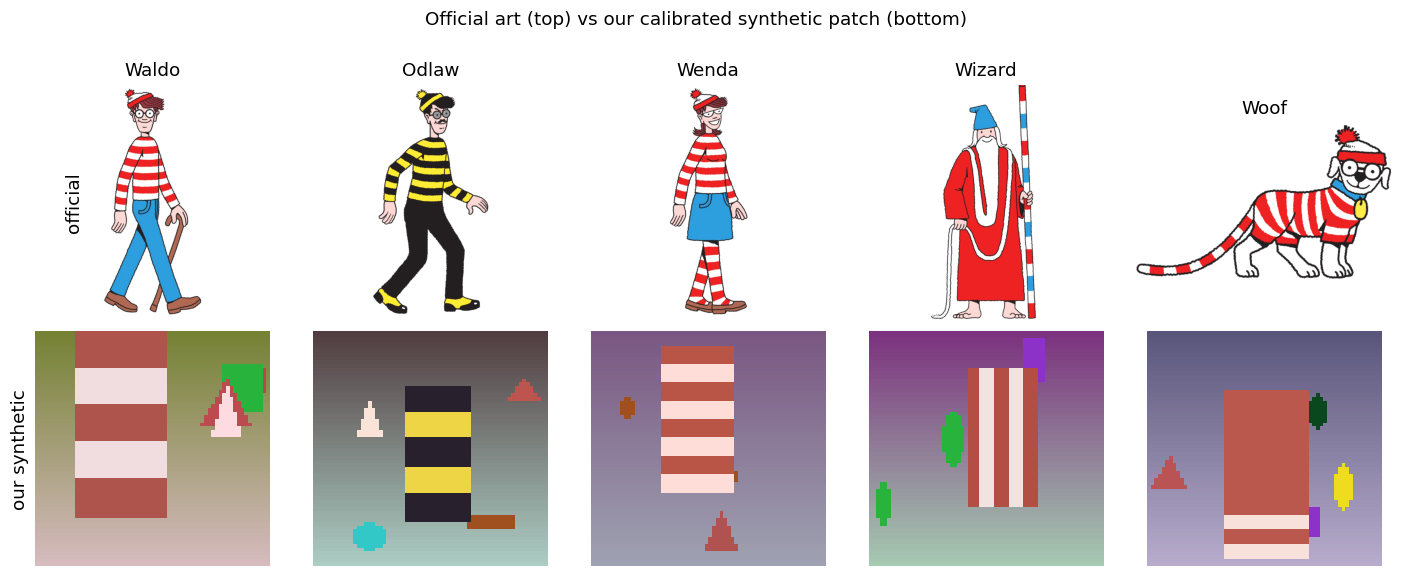

In [3]:
pairs = [('waldo', 'Waldo'), ('odlaw', 'Odlaw'), ('wenda', 'Wenda'),
         ('wizard', 'Wizard'), ('woof', 'Woof')]
def _rowlabel(a, label):
    # keep the image clean but show a row label to the LEFT (as a y-axis label)
    a.set_xticks([]); a.set_yticks([])
    for s in a.spines.values(): s.set_visible(False)
    a.set_ylabel(label, fontsize=12)
rng = np.random.default_rng(5)
fig, ax = plt.subplots(2, 5, figsize=(13, 5.2))
for j, (k, name) in enumerate(pairs):
    ax[0, j].imshow(load_char(k)); ax[0, j].set_title(name)
    patch, _ = C.render_patch(k, 64, rng, **C.PRESETS['clean'])
    ax[1, j].imshow(patch)
    if j == 0:
        _rowlabel(ax[0, j], 'official'); _rowlabel(ax[1, j], 'our synthetic')
    else:
        ax[0, j].axis('off'); ax[1, j].axis('off')
plt.suptitle('Official art (top) vs our calibrated synthetic patch (bottom)', y=1.0)
plt.tight_layout(); plt.show()

### Is this just trivially solvable?
A fair worry: if each class is defined by a single structural trait, couldn't a **simple
rule** — *"is it red? is it striped? which way?"* — just read it off, so this is no real
task for a learner? We checked. Here a deliberately simple baseline (a depth-3 decision
tree on a handful of interpretable colour/stripe statistics) sits beside a model that
**learns from the raw pixels**, on clean and full difficulty:

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

def simple_feats(X):
    """Interpretable cues a 'simple algorithm' would use: colour fractions + stripe coverage."""
    out = []
    for p in X:
        f = p.astype(np.float32)/255.0; r, g, b = f[..., 0], f[..., 1], f[..., 2]
        cm = D.colormask_3bits(p)
        red, white, dark = cm[..., 0].mean(), cm[..., 1].mean(), cm[..., 2].mean()
        yellow = ((r > 0.6) & (g > 0.5) & (b < 0.45)).mean()
        h = D.stripe_pattern_bit(p)[..., 0].mean()                                   # horizontal stripe coverage
        v = D.stripe_pattern_bit(np.ascontiguousarray(p.transpose(1, 0, 2)))[..., 0].mean()  # vertical
        out.append([red, white, dark, yellow, h, v])
    return np.array(out)

rows = []
for preset in ['clean', 'full']:
    Xtr, ytr = C.make_dataset(150, size=48, seed=1, **C.PRESETS[preset])
    Xte, yte = C.make_dataset(60, size=48, seed=2, **C.PRESETS[preset])
    simple = DecisionTreeClassifier(max_depth=3, random_state=0).fit(simple_feats(Xtr), ytr)
    f1_simple = f1_score(yte, simple.predict(simple_feats(Xte)), average='macro')
    rf = RandomForestClassifier(n_estimators=100, max_depth=14, n_jobs=-1, random_state=1)
    rf.fit(bench.raw_float(bench.to_canon(Xtr, 24)), ytr)
    f1_rf = f1_score(yte, rf.predict(bench.raw_float(bench.to_canon(Xte, 24))), average='macro')
    rows.append({'preset': preset, 'simple rule (depth-3)': round(f1_simple, 3),
                 'learns from pixels (RF)': round(f1_rf, 3)})
pd.DataFrame(rows).set_index('preset')

,simple rule (depth-3),learns from pixels (RF)
preset,,
clean,0.506,0.952
full,0.477,0.768


The simple rule reaches only **~0.5 macro-F1 even on clean patches**, while the model
that learns from pixels reaches **~0.95** — and the gap persists under difficulty. The
reason is the heart of the design: the traits that separate the look-alikes — *how many*
stripes, *where* the band sits, the *spatial arrangement* — are **not** captured by
aggregate "how red / how striped" statistics; they live in the **spatial layout**, which
a learner has to model. Switch the difficulty knobs on (rotation hides orientation,
palette-jitter blurs the colour boundary, occlusion removes the distinguishing band) and
the simple cues erode further.

So: we can't recreate Handford's puzzle, but the synthetic version is **not a give-away** —
it resists simple search and rewards a model that genuinely learns spatial pattern. That
is the regime weightless networks were built for, and the one the rest of these notebooks
explore.

## The six classes (synthetic)
One clean example of each, the form the models actually see. `background` is the
"no character" class — distractors and striped clutter, a hard negative rather than blank
canvas.

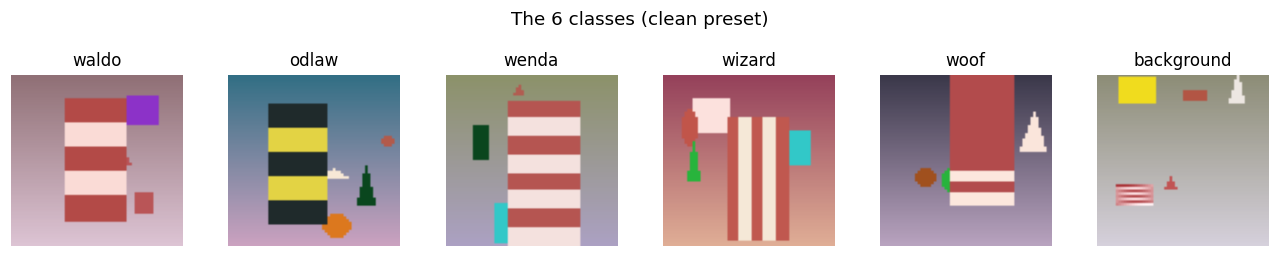

In [5]:
rng = np.random.default_rng(7)
fig, ax = plt.subplots(1, len(C.CLASSES), figsize=(2*len(C.CLASSES), 2.2))
for a, cls in zip(ax, C.CLASSES):
    patch, _ = C.render_patch(cls, 64, rng, **C.PRESETS['clean'])
    a.imshow(patch); a.set_title(cls, fontsize=11); a.axis('off')
plt.suptitle('The 6 classes (clean preset)', y=1.04); plt.tight_layout(); plt.show()

## The difficulty axes (adversary knobs)
Each preset perturbs the *same* Waldo along one axis. `full` combines them. These are
the knobs we turn to keep the comparison fair — hard for *every* model, not just the
baselines.

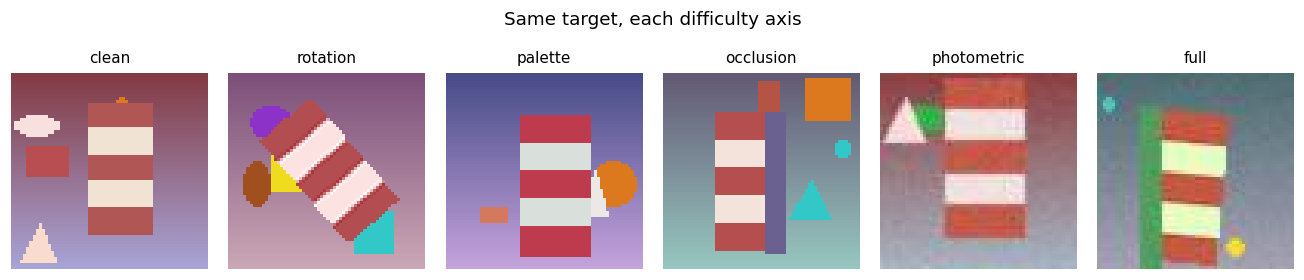

In [6]:
presets = ['clean', 'rotation', 'palette', 'occlusion', 'photometric', 'full']
fig, ax = plt.subplots(1, len(presets), figsize=(2*len(presets), 2.4))
rng = np.random.default_rng(3)
for a, p in zip(ax, presets):
    patch, _ = C.render_patch('waldo', 64, rng, **C.PRESETS[p])
    a.imshow(patch); a.set_title(p, fontsize=10); a.axis('off')
plt.suptitle('Same target, each difficulty axis', y=1.04); plt.tight_layout(); plt.show()

## A random `full`-difficulty batch
What the models actually face at maximum difficulty — mixed classes, all axes on.

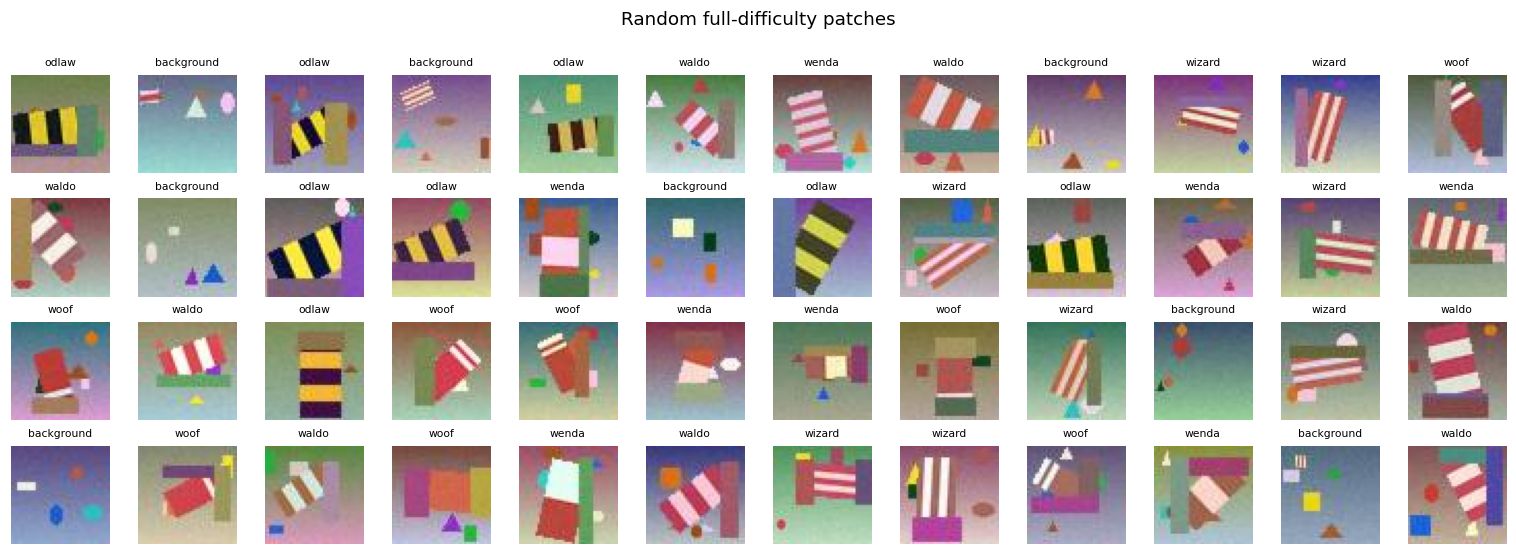

In [7]:
X, y = C.make_dataset(8, size=48, seed=11, **C.PRESETS['full'])
fig, ax = plt.subplots(4, 12, figsize=(14, 5))
for i, a in enumerate(ax.ravel()):
    a.imshow(X[i]); a.set_title(C.CLASSES[y[i]], fontsize=7); a.axis('off')
plt.suptitle('Random full-difficulty patches', y=1.0); plt.tight_layout(); plt.show()

## Calibration recap + class balance
Palette/size defaults trace to measured Hey-Waldo stats; `make_dataset` is balanced.

In [8]:
print('Calibrated palette:')
for k in ['WALDO_RED', 'WALDO_WHITE', 'ODLAW_BLACK', 'ODLAW_YELLOW']:
    print(f'  {k:14s}= {getattr(S, k)}')
X, y = C.make_dataset(100, size=48, seed=0, **C.PRESETS['clean'])
print('\nDataset shape:', X.shape, 'dtype', X.dtype)
print('Class counts:', {C.CLASSES[i]: int((y==i).sum()) for i in range(len(C.CLASSES))})

Calibrated palette:
  WALDO_RED     = (185, 84, 78)
  WALDO_WHITE   = (247, 225, 217)
  ODLAW_BLACK   = (35, 35, 40)
  ODLAW_YELLOW  = (235, 205, 60)

Dataset shape: (600, 48, 48, 3) dtype uint8
Class counts: {'waldo': 100, 'odlaw': 100, 'wenda': 100, 'wizard': 100, 'woof': 100, 'background': 100}


## Takeaways
- *Where's Waldo?* is hard **by design** — the cast (Odlaw, Wenda, Wizard, Woof) are
  engineered near-misses of Waldo's red/white-striped signature.
- We turn that into an honest 6-class recognition benchmark with calibrated, **dial-able**
  difficulty, where each confuser maps to a controllable axis (palette, stripe count,
  orientation, completeness).
- Next: **01** tunes how we *encode* patches for WiSARD (the heart of the method), **02**
  runs the honest fair comparison against tuned LR/RF with error analysis, and **03** finds
  the regime where WNN genuinely wins.